
# 규제 선형모델 예제

이 노트북은 `housing.csv` 데이터를 사용해서 다음 모델을 실습한다.

## 포함 내용

1. Ridge Regression
2. Lasso Regression
3. ElasticNet Regression

## 핵심 개념

일반 선형회귀는 오차를 줄이는 방향으로만 학습한다.  
Ridge, Lasso, ElasticNet은 오차뿐 아니라 회귀 계수의 크기도 함께 제한한다.

| 모델 | 규제 방식 |
|---|---|
| Ridge | L2 규제 |
| Lasso | L1 규제 |
| ElasticNet | L1 + L2 규제 |


In [1]:
## 데이터 처리 관련 모듈
import pandas as pd
import numpy as np

## 시각화 관련 모듈
import matplotlib.pyplot as plt

## 데이터 분리 관련 모듈
from sklearn.model_selection import train_test_split

## ML 전처리 모듈
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

## ML 자동화 관련 모듈
from sklearn.pipeline import Pipeline

## 선형회귀 및 규제 선형모델 관련 모듈
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

## 평가 지표 관련 모듈
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
## => 데이터 파일
DATA_FILE = '../Data/Numbers/housing.csv'
NAME_FILE = '../Data/Numbers/housing_title_column.txt'


## => 데이터 & 컬러명 로딩 : 첫번째 줄 컬럼명 X, 데이터 사이 공백 여러개
## - header = None
## - sep    = r'\s+'      \s : whitespace 표현식, + : 1개 이상
## - names  = housing_title_column.txt에서 지정 
with open(NAME_FILE, mode='r') as F:
    lines = F.readlines()

column_names = [ line.split(' - ')[0] for line in lines ]
df = pd.read_csv(DATA_FILE, sep=r"\s+", header=None, names=column_names )

## 데이터 앞부분 확인
display(df.head())

## 데이터 크기 확인
print("데이터 크기:", df.shape)

## 컬럼명 확인
print("컬럼명:", df.columns.tolist())


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,세금,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


데이터 크기: (506, 14)
컬럼명: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', '세금', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


In [3]:

## =========================================================
## 3. 피쳐 / 타겟 분리
## =========================================================

## MEDV 컬럼은 예측할 타겟
y = df["MEDV"]

## MEDV를 제외한 나머지 컬럼은 피쳐
X = df.drop("MEDV", axis=1)

## 훈련 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train 크기:", X_train.shape)
print("X_test 크기 :", X_test.shape)


X_train 크기: (404, 13)
X_test 크기 : (102, 13)


In [4]:

## =========================================================
## 4. 공통 평가 함수 생성
## =========================================================

def regression_evaluation(y_true, y_pred, model_name="model"):
    ## 실제값과 예측값을 받아 회귀 평가 지표 출력
    ## MSE  : 오차 제곱 평균
    ## RMSE : MSE의 제곱근
    ## MAE  : 오차 절댓값 평균
    ## R2   : 설명력

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return {
        "model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }



# 1. 기준 모델: 일반 LinearRegression

규제 모델과 비교하기 위해 일반 선형회귀를 먼저 학습한다.

규제 선형모델은 피쳐 스케일에 영향을 많이 받기 때문에 `StandardScaler`를 함께 사용한다.


In [5]:

## =========================================================
## 5. 일반 LinearRegression 모델 학습
## =========================================================

## StandardScaler와 LinearRegression을 Pipeline으로 연결
linear_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

## 모델 학습
linear_pipe.fit(X_train, y_train)

## 예측
y_pred_linear = linear_pipe.predict(X_test)

## 평가
result_linear = regression_evaluation(
    y_test,
    y_pred_linear,
    model_name="LinearRegression"
)


LinearRegression
MSE : 24.29111947497352
RMSE: 4.928602182665337
MAE : 3.189091965887848
R2  : 0.668759493535632



# 2. Ridge Regression

Ridge는 L2 규제를 사용하는 선형회귀 모델이다.

L2 규제는 회귀 계수가 너무 커지지 않도록 제한한다.

## 특징

- 모든 피쳐를 대체로 유지
- 계수 크기를 줄임
- 과대적합 완화에 사용
- `alpha`가 클수록 규제가 강해짐


In [6]:

## =========================================================
## 6. Ridge 모델 학습
## =========================================================

## Ridge 모델 생성
## alpha는 규제 강도
## alpha가 커질수록 회귀 계수를 더 강하게 줄임
ridge_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

## 모델 학습
ridge_pipe.fit(X_train, y_train)

## 예측
y_pred_ridge = ridge_pipe.predict(X_test)

## 평가
result_ridge = regression_evaluation(
    y_test,
    y_pred_ridge,
    model_name="Ridge alpha=1.0"
)


Ridge alpha=1.0
MSE : 24.31290383049162
RMSE: 4.930811680696356
MAE : 3.185723807244597
R2  : 0.6684624359643558



# 3. Lasso Regression

Lasso는 L1 규제를 사용하는 선형회귀 모델이다.

L1 규제는 일부 회귀 계수를 0으로 만들 수 있다.

## 특징

- 중요하지 않은 피쳐의 계수를 0으로 만들 수 있음
- 피쳐 선택 효과
- `alpha`가 너무 크면 많은 피쳐가 제거될 수 있음


In [7]:

## =========================================================
## 7. Lasso 모델 학습
## =========================================================

## Lasso 모델 생성
## max_iter는 최적화 반복 횟수
## alpha가 커질수록 더 많은 계수가 0에 가까워지거나 0이 될 수 있음
lasso_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1, max_iter=10000, random_state=42))
])

## 모델 학습
lasso_pipe.fit(X_train, y_train)

## 예측
y_pred_lasso = lasso_pipe.predict(X_test)

## 평가
result_lasso = regression_evaluation(
    y_test,
    y_pred_lasso,
    model_name="Lasso alpha=0.1"
)


Lasso alpha=0.1
MSE : 25.65673936716768
RMSE: 5.065248203905479
MAE : 3.241803465879464
R2  : 0.6501375183238987



# 4. ElasticNet Regression

ElasticNet은 Ridge의 L2 규제와 Lasso의 L1 규제를 함께 사용하는 모델이다.

## 특징

- L1 규제와 L2 규제를 함께 사용
- `alpha`는 전체 규제 강도
- `l1_ratio`는 L1 규제 비율
- `l1_ratio=1`이면 Lasso와 유사
- `l1_ratio=0`이면 Ridge와 유사


In [8]:

## =========================================================
## 8. ElasticNet 모델 학습
## =========================================================

## ElasticNet 모델 생성
## alpha는 전체 규제 강도
## l1_ratio는 L1 규제 비율
## l1_ratio=0.5는 L1과 L2를 절반씩 사용한다는 의미
elastic_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=42))
])

## 모델 학습
elastic_pipe.fit(X_train, y_train)

## 예측
y_pred_elastic = elastic_pipe.predict(X_test)

## 평가
result_elastic = regression_evaluation(
    y_test,
    y_pred_elastic,
    model_name="ElasticNet alpha=0.1 l1_ratio=0.5"
)


ElasticNet alpha=0.1 l1_ratio=0.5
MSE : 25.2035529568404
RMSE: 5.020314029703759
MAE : 3.1920909142714433
R2  : 0.6563172951034018


,model,MSE,RMSE,MAE,R2
0,LinearRegression,24.291119,4.928602,3.189092,0.668759
1,Ridge alpha=1.0,24.312904,4.930812,3.185724,0.668462
2,Lasso alpha=0.1,25.656739,5.065248,3.241803,0.650138
3,ElasticNet alpha=0.1 l1_ratio=0.5,25.203553,5.020314,3.192091,0.656317


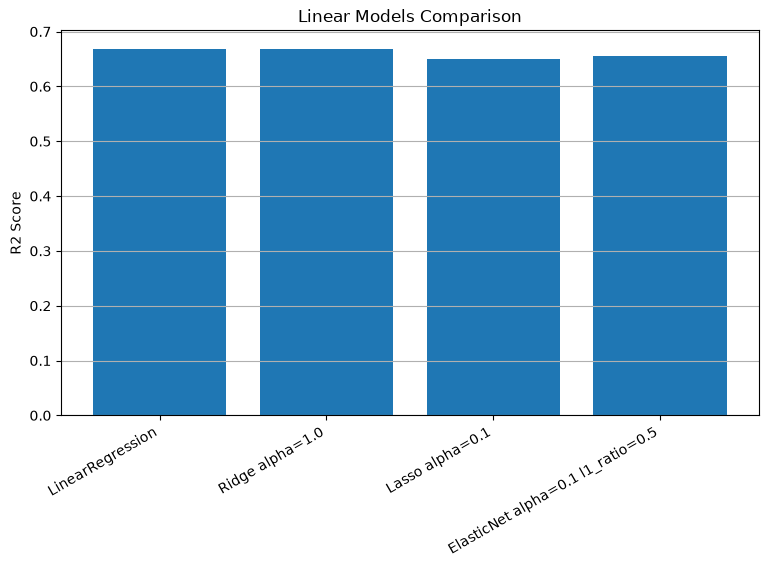

In [9]:

## =========================================================
## 9. 네 모델 평가 결과 비교
## =========================================================

## 평가 결과를 DataFrame으로 정리
result_df = pd.DataFrame([
    result_linear,
    result_ridge,
    result_lasso,
    result_elastic
])

display(result_df)

## R2 기준 비교 시각화
plt.figure(figsize=(9, 5))
plt.bar(result_df["model"], result_df["R2"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("R2 Score")
plt.title("Linear Models Comparison")
plt.grid(axis="y")
plt.show()


In [10]:

## =========================================================
## 10. 회귀 계수 비교
## =========================================================

## Pipeline에서 학습된 모델 꺼내기
linear_model = linear_pipe.named_steps["model"]
ridge_model = ridge_pipe.named_steps["model"]
lasso_model = lasso_pipe.named_steps["model"]
elastic_model = elastic_pipe.named_steps["model"]

## 각 모델의 회귀 계수 DataFrame 생성
coef_df = pd.DataFrame({
    "feature": X.columns,
    "LinearRegression": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
    "ElasticNet": elastic_model.coef_
})

display(coef_df)

## Lasso에서 계수가 0인 피쳐 확인
zero_lasso = coef_df[coef_df["Lasso"] == 0]["feature"].tolist()

print("Lasso에서 계수가 0인 피쳐:")
print(zero_lasso)


,feature,LinearRegression,Ridge,Lasso,ElasticNet
0,CRIM,-1.002135,-0.992187,-0.718365,-0.761221
1,ZN,0.696269,0.677749,0.259627,0.322227
2,INDUS,0.278065,0.252214,-0.000000,-0.031008
3,CHAS,0.718738,0.722481,0.698221,0.736913
4,NOX,-2.022319,-1.990835,-1.568142,-1.395953
5,RM,3.145240,3.151572,3.271507,3.233606
6,AGE,-0.176048,-0.177262,-0.000000,-0.096111
7,DIS,-3.081908,-3.045029,-2.284449,-2.175919
8,RAD,2.251407,2.173249,0.671938,0.846537
9,세금,-1.767014,-1.695559,-0.356654,-0.623952


Lasso에서 계수가 0인 피쳐:
['INDUS', 'AGE']


c:\Users\Win11Pro\anaconda3\envs\ML_ENV11\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Win11Pro\anaconda3\envs\ML_ENV11\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


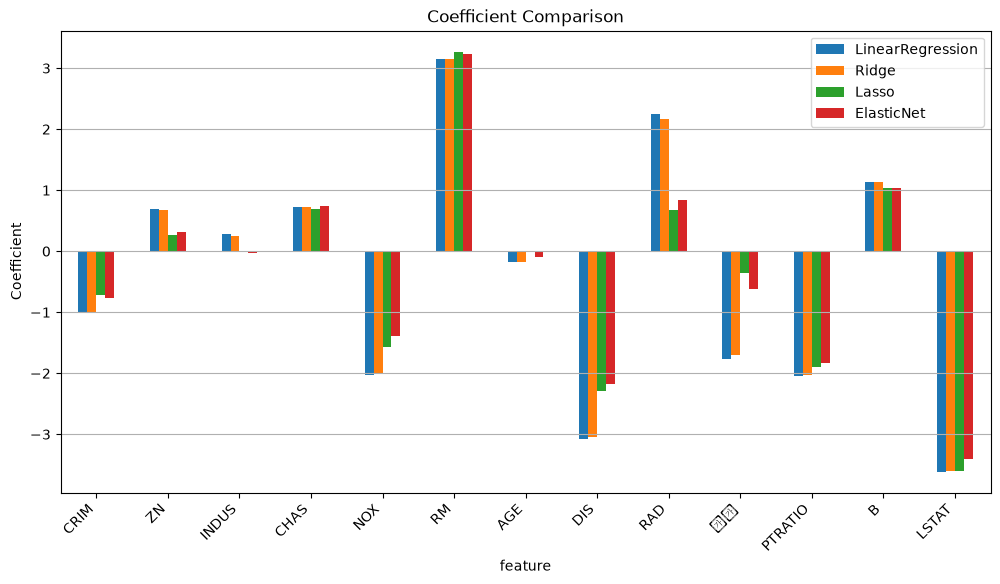

In [11]:

## =========================================================
## 11. 회귀 계수 시각화
## =========================================================

## 피쳐별 회귀 계수를 비교하기 위해 feature를 index로 설정
coef_plot_df = coef_df.set_index("feature")

## 계수 비교 그래프
coef_plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Coefficient Comparison")
plt.ylabel("Coefficient")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()



# 5. alpha 값 변화 비교

`alpha`는 규제 강도를 의미한다.

- `alpha`가 작으면 규제가 약함
- `alpha`가 크면 규제가 강함
- 규제가 너무 약하면 과대적합 가능성
- 규제가 너무 강하면 과소적합 가능성


,alpha,R2,RMSE
0,0.001,0.668759,4.928604
1,0.010,0.668757,4.928624
2,0.100,0.668730,4.928823
3,1.000,0.668462,4.930812
4,10.000,0.665968,4.949328
5,100.000,0.654626,5.032650


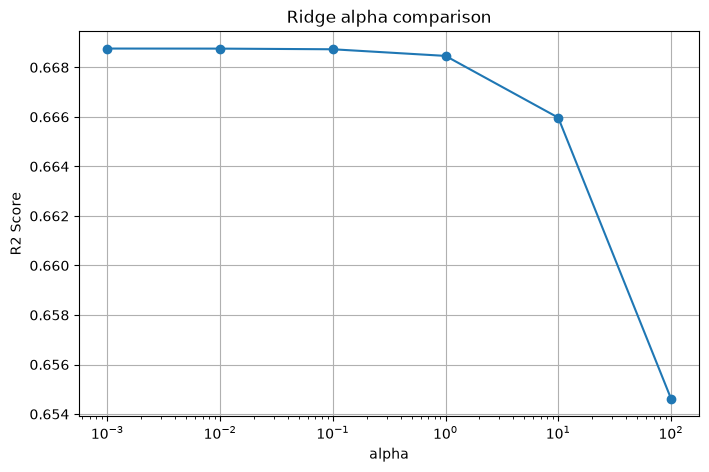

In [12]:

## =========================================================
## 12. alpha 값 변화에 따른 Ridge 성능 비교
## =========================================================

## 실험할 alpha 후보
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

## 결과 저장 리스트
ridge_results = []

for alpha in alpha_list:
    ## alpha별 Ridge Pipeline 생성
    pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha, random_state=42))
    ])

    ## 모델 학습
    pipe.fit(X_train, y_train)

    ## 예측
    pred = pipe.predict(X_test)

    ## 평가 지표 계산
    ridge_results.append({
        "alpha": alpha,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred))
    })

## 결과 DataFrame 생성
ridge_result_df = pd.DataFrame(ridge_results)

display(ridge_result_df)

## alpha별 R2 시각화
plt.figure(figsize=(8, 5))
plt.plot(ridge_result_df["alpha"], ridge_result_df["R2"], marker="o")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("R2 Score")
plt.title("Ridge alpha comparison")
plt.grid(True)
plt.show()


,alpha,R2,RMSE,zero_coef_count
0,0.001,0.668713,4.928949,0
1,0.010,0.668182,4.932900,0
2,0.100,0.650138,5.065248,2
3,1.000,0.623943,5.251447,7
4,10.000,-0.023341,8.662877,13


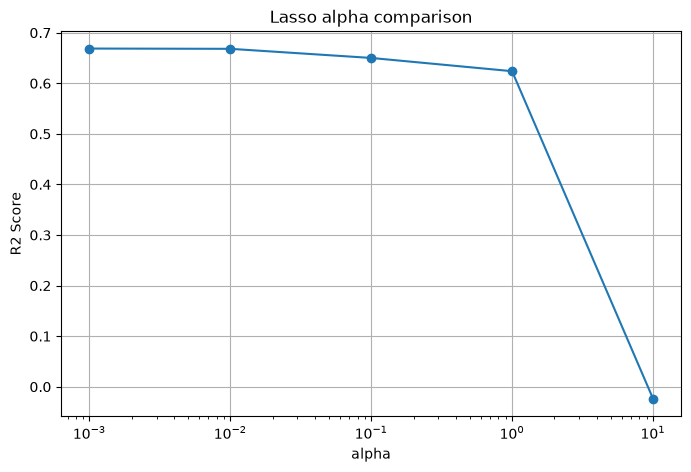

In [13]:

## =========================================================
## 13. alpha 값 변화에 따른 Lasso 성능 비교
## =========================================================

## 실험할 alpha 후보
alpha_list = [0.001, 0.01, 0.1, 1, 10]

## 결과 저장 리스트
lasso_results = []

for alpha in alpha_list:
    ## alpha별 Lasso Pipeline 생성
    pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=10000, random_state=42))
    ])

    ## 모델 학습
    pipe.fit(X_train, y_train)

    ## 예측
    pred = pipe.predict(X_test)

    ## 학습된 Lasso 모델 꺼내기
    fitted_lasso = pipe.named_steps["model"]

    ## 계수가 0인 피쳐 개수 계산
    zero_count = np.sum(fitted_lasso.coef_ == 0)

    ## 평가 지표 저장
    lasso_results.append({
        "alpha": alpha,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "zero_coef_count": zero_count
    })

## 결과 DataFrame 생성
lasso_result_df = pd.DataFrame(lasso_results)

display(lasso_result_df)

## alpha별 R2 시각화
plt.figure(figsize=(8, 5))
plt.plot(lasso_result_df["alpha"], lasso_result_df["R2"], marker="o")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("R2 Score")
plt.title("Lasso alpha comparison")
plt.grid(True)
plt.show()



## 최종 정리

| 모델 | 규제 | 특징 |
|---|---|---|
| LinearRegression | 없음 | 기준 모델 |
| Ridge | L2 | 계수 크기를 전체적으로 줄임 |
| Lasso | L1 | 일부 계수를 0으로 만들 수 있음 |
| ElasticNet | L1 + L2 | Ridge와 Lasso의 절충 |

규제 선형모델은 피쳐 스케일의 영향을 받기 때문에 `StandardScaler`와 함께 사용하는 것이 일반적이다.
